# Operational Efficiency Analysis

## Incident Workflow, SLA Performance & Process Bottleneck Analysis

In [1]:
# Завантаження бібліотек
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
import statsmodels.api as sm

from google.cloud import bigquery

# 1. Бізнес-проблема та мета проєкту

У багатьох компаніях ефективність процесів incident management напряму впливає на швидкість обробки задач, навантаження на команди та загальну операційну ефективність. Затримки у вирішенні інцидентів, велика кількість escalation та неефективні workflow можуть створювати bottlenecks і ускладнювати роботу команд.

Метою цього проєкту є аналіз процесу обробки інцидентів для виявлення проблемних зон у workflow, оцінки resolution time, розподілу workload та факторів, що впливають на operational efficiency.

У рамках проєкту буде проведено аналіз:

- workflow інцидентів;
- SLA breaches та escalation process;
- workload distribution;
- reopened incidents;
- факторів, що впливають на resolution time та operational efficiency.

Також будуть сформовані рекомендації для оптимізації workflow.

Для реалізації проєкту використано наступні інструменти та методи аналізу:

- Python/Pandas/Plotly – для обробки даних, feature engineering, аналізу та візуалізації;
- BigQuery/SQL – для зберігання даних та виконання business queries;
- Statistical Testing – для перевірки гіпотез та оцінки взаємозв’язків між operational metrics (t-test, Pearson correlation analysis).

# 2. Огляд та структура датасету

У даному розділі проводиться первинний огляд датасету, аналіз структури даних та перевірка основних характеристик набору даних, необхідних для подальшого operational analysis.

In [2]:
# Завантаження даних
df = pd.read_csv('data/incident_management.csv', sep=';')

In [3]:
# Перегляд перших рядків датасету
df.head()

,Case ID,Variant,Priority,Reporter,Timestamp,Event,Issue Type,Resolver,Report Channel,Short Description,Customer Satisfaction
0,INC0001,Variant 4,Medium,Alice,17/11/2023 11:17,Ticket created,Performance Issue,NaN,Website,Application crash,3
1,INC0001,Variant 4,Medium,Alice,17/11/2023 13:30,Ticket assigned to level 1 support,Performance Issue,Sam,Website,Application crash,3
2,INC0001,Variant 4,Medium,Alice,17/11/2023 14:06,WIP - level 1 support,Performance Issue,Sam,Website,Application crash,3
3,INC0001,Variant 4,Medium,Alice,17/11/2023 16:52,Level 1 escalates to level 2 support,Performance Issue,Michael,Website,Application crash,3
4,INC0001,Variant 4,Medium,Alice,17/11/2023 18:07,WIP - level 2 support,Performance Issue,Emma,Website,Application crash,3


In [4]:
# Перевірка розміру датасету
df.shape

(242901, 11)

In [5]:
# Перевірка типів даних та загальної структури
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242901 entries, 0 to 242900
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Case ID                242901 non-null  object
 1   Variant                242901 non-null  object
 2   Priority               242901 non-null  object
 3   Reporter               242901 non-null  object
 4   Timestamp              242901 non-null  object
 5   Event                  242901 non-null  object
 6   Issue Type             242901 non-null  object
 7   Resolver               146405 non-null  object
 8   Report Channel         242901 non-null  object
 9   Short Description      242901 non-null  object
 10  Customer Satisfaction  242901 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 20.4+ MB


In [6]:
# Перевірка missing values
df.isnull().sum()

Case ID                      0
Variant                      0
Priority                     0
Reporter                     0
Timestamp                    0
Event                        0
Issue Type                   0
Resolver                 96496
Report Channel               0
Short Description            0
Customer Satisfaction        0
dtype: int64

Датасет містить 242 901 рядок та 11 колонок. Кожен рядок відповідає окремій події в межах incident management workflow.

У даних присутні ключові поля для operational analysis: Case ID, Timestamp, Event, Priority, Issue Type, Resolver, Report Channel, Customer Satisfaction.

Поле Resolver має 96 496 пропущених значень. Це може бути логічним для подій, де виконавець ще не призначений, наприклад, Ticket created. Тому ці пропуски потрібно буде перевірити окремо в розділі Перевірка якості даних.

# 3. Перевірка якості даних

У даному розділі проводиться перевірка якості даних для виявлення potential issues, які можуть впливати на коректність подальшого аналізу. Зокрема перевіряються дублікати, пропущені значення, типи даних та коректність timestamp-полів.

In [7]:
# Перевірка кількості дублікатів
df.duplicated().sum()

np.int64(0)

In [8]:
# Кількість унікальних інцидентів
df['Case ID'].nunique()

31588

In [9]:
# Кількість унікальних типів подій
df['Event'].nunique()

18

In [10]:
# Перегляд унікальних подій workflow
df['Event'].unique()

array(['Ticket created', 'Ticket assigned to level 1 support',
       'WIP - level 1 support', 'Level 1 escalates to level 2 support',
       'WIP - level 2 support', 'Ticket solved by level 2 support',
       'Ticket closed', 'Customer feedback received',
       'Ticket escalated to level 2 support',
       'Ticket solved by level 1 support',
       'Level 2 escalates to level 3 support', 'WIP - level 3 support',
       'Ticket assigned to level 2 support',
       'Ticket rejected by level 1 support',
       'Ticket reopened by customer', 'Ticket solved by level 3 support',
       'Level 2 support rejects the ticket', ' '], dtype=object)

In [11]:
# Конвертація Timestamp у datetime формат
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

In [12]:
# Перевірка типу Timestamp після конвертації
df['Timestamp'].dtype

dtype('<M8[ns]')

In [13]:
# Перевірка кількості missing values у Resolver
df['Resolver'].isnull().sum()

np.int64(96496)

In [14]:
# Аналіз events із пропущеними значеннями у Resolver
null_resolver_events = (
    df[df['Resolver'].isnull()]['Event']
    .value_counts()
)

print(null_resolver_events)

Event
Ticket closed                         32776
Ticket created                        31588
Customer feedback received            30338
Ticket reopened by customer            1188
Level 2 support rejects the ticket      606
Name: count, dtype: int64


In [15]:
# Частка пропущених значень у Resolver
null_resolver_rate = df['Resolver'].isnull().mean() * 100

print(f'Null Resolver rate: {null_resolver_rate:.1f}%')

Null Resolver rate: 39.7%


#### Висновки

У результаті перевірки якості даних встановлено, що датасет не має дублікатів і є придатним для подальшого аналізу.

Датасет містить 31 588 унікальних інцидентів та 18 типів workflow events, що дозволяє аналізувати lifecycle інцидентів, escalation flows та process bottlenecks.

Також виявлено 96 496 пропущених значень (39,7%) у колонці Resolver. Додатковий аналіз підтвердив, що це структурна особливість процесу: всі null-значення належать до системних подій (Ticket created, Ticket closed та Customer feedback received), де призначення виконавця не передбачено workflow. Критичних проблем якості даних не виявлено.

# 4. Формування operational metrics та feature engineering

Для подальшого аналізу операційної ефективності необхідно перейти від event-level до incident-level представлення даних. Оскільки початковий датасет містить окремі події в межах кожного інциденту, на цьому етапі формуються агреговані operational metrics для аналізу процесу на рівні incident cases.

У межах feature engineering будуть розраховані ключові операційні показники: resolution time, escalation count, SLA status та часові характеристики workload distribution.

In [16]:
# Формування incident-level dataset
incident_df = df.groupby('Case ID').agg(
    first_event_time = ('Timestamp', 'min'),
    last_event_time = ('Timestamp', 'max'),
    total_events = ('Event', 'count'),
    priority = ('Priority', 'first'),
    issue_type = ('Issue Type', 'first'),
    report_channel = ('Report Channel', 'first'),
    variant = ('Variant', 'first'),
    csat = ('Customer Satisfaction', 'first')
).reset_index()

In [17]:
# Розрахунок загального часу проходження (в годинах) інциденту через workflow
incident_df['resolution_hours'] = (
    incident_df['last_event_time'] - incident_df['first_event_time']
).dt.total_seconds() / 3600

incident_df[['Case ID', 'first_event_time', 'last_event_time', 'resolution_hours']].head()

,Case ID,first_event_time,last_event_time,resolution_hours
0,INC0001,2023-11-17 11:17:00,2023-11-17 21:28:00,10.183333
1,INC0002,2023-08-15 07:08:00,2023-08-15 12:51:00,5.716667
2,INC0003,2023-11-23 19:27:00,2023-11-24 03:25:00,7.966667
3,INC0004,2023-09-20 18:56:00,2023-09-21 04:30:00,9.566667
4,INC0005,2023-07-11 12:47:00,2023-07-12 18:39:00,29.866667


Для аналізу SLA performance у проєкті використовуються умовні SLA thresholds залежно від priority інциденту. Оскільки у датасеті відсутня окрема SLA-колонка, thresholds були сформовані відповідно до типових практик incident management.

In [18]:
# Створення умовних SLA thresholds залежно від priority
sla_map = {
    'Critical': 4,
    'High': 8,
    'Medium': 24,
    'Low': 72
}

# Додавання SLA threshold для кожного інциденту
incident_df['sla_threshold_hours'] = incident_df['priority'].map(sla_map)

# Визначення інцидентів, що порушили SLA
incident_df['sla_breached'] = (
    incident_df['resolution_hours'] > incident_df['sla_threshold_hours']
)

incident_df[
    [
        'Case ID',
        'priority',
        'resolution_hours',
        'sla_threshold_hours',
        'sla_breached'
    ]
].head()

,Case ID,priority,resolution_hours,sla_threshold_hours,sla_breached
0,INC0001,Medium,10.183333,24,False
1,INC0002,High,5.716667,8,False
2,INC0003,High,7.966667,8,False
3,INC0004,Medium,9.566667,24,False
4,INC0005,Low,29.866667,72,False


In [19]:
# Події, які вважаються escalation events
escalation_events = [
    'Level 1 escalates to level 2 support',
    'Level 2 escalates to level 3 support',
    'Ticket escalated to level 2 support'
]

# Розрахунок кількості escalation events для кожного інциденту
escalation_counts = (
    df[df['Event'].isin(escalation_events)]
    .groupby('Case ID')
    .size()
    .reset_index(name='escalation_count')
)

# Додавання escalation metrics до incident-level dataset
incident_df = incident_df.merge(
    escalation_counts,
    on='Case ID',
    how='left'
)

incident_df['escalation_count'] = (
    incident_df['escalation_count']
    .fillna(0)
    .astype(int)
)

incident_df[
    ['Case ID', 'total_events', 'escalation_count']
].head()

,Case ID,total_events,escalation_count
0,INC0001,7,1
1,INC0002,8,1
2,INC0003,10,1
3,INC0004,6,0
4,INC0005,8,1


In [20]:
# Створення часових ознак для workload analysis
incident_df['open_hour'] = incident_df['first_event_time'].dt.hour
incident_df['open_day'] = incident_df['first_event_time'].dt.day_name()

incident_df[['Case ID', 'first_event_time', 'open_day', 'open_hour']].head()

,Case ID,first_event_time,open_day,open_hour
0,INC0001,2023-11-17 11:17:00,Friday,11
1,INC0002,2023-08-15 07:08:00,Tuesday,7
2,INC0003,2023-11-23 19:27:00,Thursday,19
3,INC0004,2023-09-20 18:56:00,Wednesday,18
4,INC0005,2023-07-11 12:47:00,Tuesday,12


In [21]:
# Додаткові operational flags

# Чи був інцидент ескалований
incident_df['is_escalated'] = incident_df['escalation_count'] > 0

# Case IDs інцидентів, які були reopened
reopened_cases = (
    df[df['Event'] == 'Ticket reopened by customer']['Case ID']
    .unique()
)

# Чи був інцидент повторно відкритий клієнтом
incident_df['is_reopened'] = incident_df['Case ID'].isin(reopened_cases)

# Швидка перевірка
print(
    f"Escalated incidents: "
    f"{incident_df['is_escalated'].sum():,} "
    f"({incident_df['is_escalated'].mean() * 100:.1f}%)"
)

print(
    f"Reopened incidents: "
    f"{incident_df['is_reopened'].sum():,} "
    f"({incident_df['is_reopened'].mean() * 100:.1f}%)"
)

Escalated incidents: 18,841 (59.6%)
Reopened incidents: 1,188 (3.8%)


In [22]:
# Перевірка розміру сформованого incident-level dataset
print(f'Incident-level dataset shape: {incident_df.shape}')

incident_df.head()

Incident-level dataset shape: (31588, 17)


,Case ID,first_event_time,last_event_time,total_events,priority,issue_type,report_channel,variant,csat,resolution_hours,sla_threshold_hours,sla_breached,escalation_count,open_hour,open_day,is_escalated,is_reopened
0,INC0001,2023-11-17 11:17:00,2023-11-17 21:28:00,7,Medium,Performance Issue,Website,Variant 4,3,10.183333,24,False,1,11,Friday,True,False
1,INC0002,2023-08-15 07:08:00,2023-08-15 12:51:00,8,High,Performance Issue,App,Variant 3,3,5.716667,8,False,1,7,Tuesday,True,False
2,INC0003,2023-11-23 19:27:00,2023-11-24 03:25:00,10,High,Feature Request,Website,Variant 9,4,7.966667,8,False,1,19,Thursday,True,False
3,INC0004,2023-09-20 18:56:00,2023-09-21 04:30:00,6,Medium,Incident,Email,Variant 1,4,9.566667,24,False,0,18,Wednesday,False,False
4,INC0005,2023-07-11 12:47:00,2023-07-12 18:39:00,8,Low,Performance Issue,Website,Variant 3,3,29.866667,72,False,1,12,Tuesday,True,False


У результаті feature engineering event-level dataset було трансформовано в incident-level dataset, де кожен рядок відповідає окремому інциденту.

На цьому етапі були сформовані ключові operational metrics для подальшого аналізу:

- resolution time;
- escalation count;
- SLA status;
- часові характеристики workload;
- escalation та reopened flags.

Додатковий аналіз показав, що 59,6% інцидентів проходили через escalation process, а 3,8% інцидентів були reopened після первинного вирішення.

Сформований набір даних дозволяє перейти до аналізу operational efficiency, workload distribution, SLA performance та process bottlenecks.

Сформований incident-level dataset завантажується до BigQuery для подальшого SQL-аналізу та дослідження даних.

# 5. SQL та BigQuery: аналіз ключових operational metrics

У цьому розділі incident-level dataset використовується для аналізу операційної ефективності процесу обробки інцидентів за допомогою SQL, BigQuery та Python.

Основна увага приділяється:

- SLA performance;
- workload distribution;
- escalation patterns;
- workflow bottlenecks;
- факторам, що впливають на operational efficiency.

Аналіз побудований у форматі business questions із використанням SQL для отримання даних та Python для аналізу і візуалізації результатів.

### Підключення до BigQuery та завантаження incident-level dataset

In [23]:
# Підключення до BigQuery
client = bigquery.Client(
    project='operational-efficiency-project'
)

print('BigQuery connection successful')

BigQuery connection successful


In [24]:
# Створення dataset у BigQuery для збереження operational metrics
dataset_id = 'operational-efficiency-project.operational_efficiency'

dataset = bigquery.Dataset(dataset_id)
dataset.location = 'EU'

dataset = client.create_dataset(
    dataset,
    exists_ok=True
)

print(f'Dataset ready: {dataset.dataset_id}')

Dataset ready: operational_efficiency


In [25]:
# Завантаження incident-level dataset у BigQuery table
table_id = 'operational-efficiency-project.operational_efficiency.incident_metrics'

# Перезапис таблиці при повторному запуску notebook
job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_TRUNCATE'
)

job = client.load_table_from_dataframe(
    incident_df,
    table_id,
    job_config=job_config
)

job.result()

print(f'Data uploaded to BigQuery table: {table_id}')

Data uploaded to BigQuery table: operational-efficiency-project.operational_efficiency.incident_metrics


### Перевірка структури priority categories

Перед проведенням operational analysis перевіримо структуру priority categories у сформованому incident-level dataset.

In [26]:
# Перевірка унікальних значень priority
print(incident_df['priority'].value_counts())

priority
Medium    15774
Low        9348
High       6466
Name: count, dtype: int64


У датасеті відсутні інциденти з рівнем Critical priority, що може бути пов’язано зі специфікою процесу або особливостями класифікації інцидентів у компанії.

### Business Question 1: Який розподіл інцидентів за priority та issue type?

Для оцінки структури operational workload проаналізуємо розподіл інцидентів за рівнем priority та типом issue. Це дозволить визначити, які категорії інцидентів формують основне навантаження.

In [27]:
# SQL-запит для аналізу розподілу інцидентів
# за priority та issue type
query = """
SELECT
    priority,
    issue_type,
    COUNT(*) AS incident_count
FROM `operational-efficiency-project.operational_efficiency.incident_metrics`
GROUP BY priority, issue_type
ORDER BY priority, incident_count DESC
"""

# Отримання результатів з BigQuery
priority_issue_summary = client.query(query).to_dataframe()

priority_issue_summary.head(10)

,priority,issue_type,incident_count
0,High,Performance Issue,1650
1,High,Bug,1388
2,High,Feature Request,1236
3,High,Incident,902
4,High,Service Request,651
5,High,Maintenance,327
6,High,Technical Issue,312
7,Low,Performance Issue,2365
8,Low,Bug,2046
9,Low,Feature Request,1809


In [28]:
# Розподіл інцидентів за priority (%)
priority_distribution = (
    incident_df['priority']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

priority_distribution

priority
Medium    49.9
Low       29.6
High      20.5
Name: proportion, dtype: float64

In [29]:
# Пастельна кольорова палітра для візуалізацій
pastel_palette = [
    '#A8CBE6',  # pastel blue
    '#B7DFC5',  # mint green
    '#F6D49A',  # soft pastel orange
    '#C8B6E8',  # pastel lavender
    '#F2B8B5',  # soft coral pink
    '#8FBCE6',  # sky blue
    '#C7D9A5'   # soft olive
]

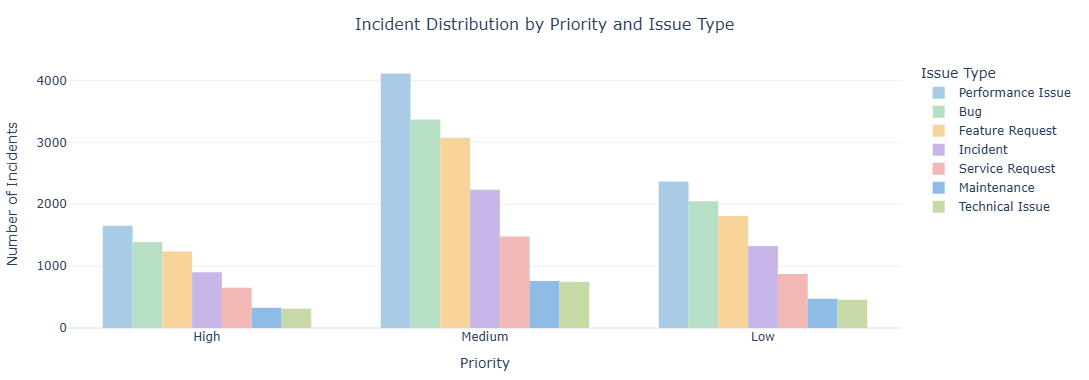

In [30]:
# Логічний порядок priority categories
priority_order = ['High', 'Medium', 'Low']

# Побудова compact bar chart для аналізу розподілу інцидентів
fig = px.bar(
    priority_issue_summary,
    x='priority',
    y='incident_count',
    color='issue_type',
    barmode='group',
    category_orders={'priority': priority_order},
    title='Incident Distribution by Priority and Issue Type',
    color_discrete_sequence=pastel_palette,
    labels={
        'incident_count': 'Number of Incidents',
        'priority': 'Priority',
        'issue_type': 'Issue Type'
    }
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=16),
    font=dict(size=12),
    legend_title='Issue Type',
    height=380,
    bargap=0.25,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.update_traces(
    marker_line_width=0
)

fig.show()

### Аналіз результатів

Medium priority формує 49,9% операційного навантаження (15 774 інциденти), Low – 29,6%, High – 20,5%. Performance Issues домінують у всіх категоріях. Попри найменшу кількість, High priority інциденти мають найбільший вплив на SLA performance та операційну стабільність.

### Business Question 2: Який середній час вирішення інцидентів залежно від priority?

Аналізуємо середній час вирішення інцидентів залежно від рівня пріоритету. Це дозволяє оцінити відповідність операційних процесів SLA-вимогам.

In [31]:
# Розрахунок resolution time metrics за priority
resolution_by_priority = (
    incident_df
    .groupby('priority')
    .agg(
        avg_hours=('resolution_hours', 'mean'),
        median_hours=('resolution_hours', 'median'),
        max_hours=('resolution_hours', 'max'),
        incident_count=('Case ID', 'count'),
        sla_threshold=('sla_threshold_hours', 'first')
    )
    .round(1)
    .reset_index()
)

# Логічний порядок priority categories
priority_order = ['High', 'Medium', 'Low']

resolution_by_priority['priority'] = pd.Categorical(
    resolution_by_priority['priority'],
    categories=priority_order,
    ordered=True
)

resolution_by_priority = resolution_by_priority.sort_values('priority')
resolution_by_priority

,priority,avg_hours,median_hours,max_hours,incident_count,sla_threshold
0,High,6.2,6.0,13.5,6466,8
2,Medium,12.3,11.9,27.7,15774,24
1,Low,25.8,25.1,56.3,9348,72


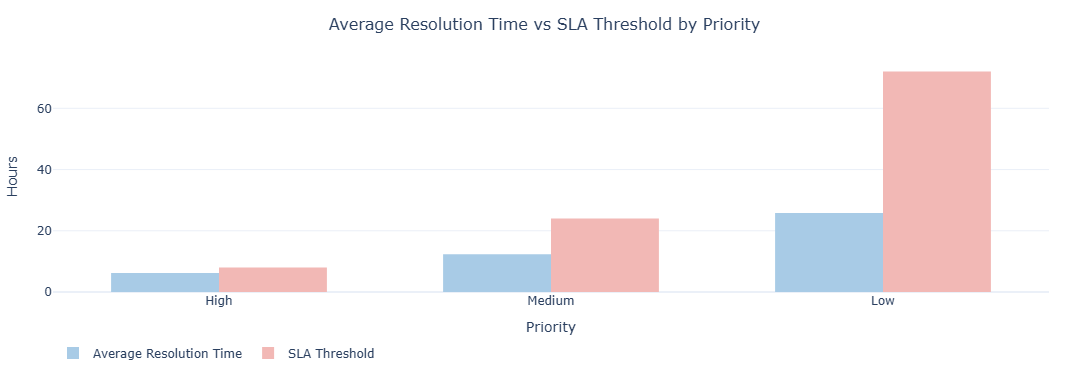

In [32]:
# Побудова grouped bar chart:
# Average Resolution time vs SLA threshold

fig = go.Figure()

fig.add_bar(
    x=resolution_by_priority['priority'],
    y=resolution_by_priority['avg_hours'],
    name='Average Resolution Time',
    marker_color='#A8CBE6'
)

fig.add_bar(
    x=resolution_by_priority['priority'],
    y=resolution_by_priority['sla_threshold'],
    name='SLA Threshold',
    marker_color='#F2B8B5'
)

fig.update_layout(
    barmode='group',
    title='Average Resolution Time vs SLA Threshold by Priority',
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=16),
    font=dict(size=12),
    yaxis_title='Hours',
    xaxis_title='Priority',
    height=380,
    bargap=0.35,
    margin=dict(l=40, r=40, t=60, b=40),
    legend=dict(
        orientation='h',
        y=-0.2
    )
)

fig.update_traces(
    marker_line_width=0
)

fig.show()

### Аналіз результатів

Середній час вирішення інцидентів зростає зі зниженням priority: High priority incidents вирішуються в середньому за 6,2 години, Medium – за 12,3 години, Low – за 25,8 години.

Усі priority categories у середньому вкладаються в умовні SLA thresholds. Це свідчить про відносно стабільний рівень SLA performance на агрегованому рівні.

Водночас окремі інциденти мають значно вищий resolution time порівняно із середніми значеннями, особливо серед Low priority incidents. Це може свідчити про нерівномірність workload або складніші кейси в окремих категоріях інцидентів.

### Business Question 3: Який відсоток інцидентів порушує SLA?

Аналізуємо рівень SLA-відповідності по кожному priority. SLA breach визначається як перевищення встановленого порогового часу вирішення. Це дозволяє визначити, які інциденти найчастіше не вкладаються у встановлені SLA thresholds.

In [33]:
# SQL-запит для розрахунку SLA breach rate по кожному priority
query = """
SELECT
    priority,
    COUNT(*) AS total_incidents,
    COUNTIF(sla_breached) AS breached_count,
    ROUND(
        COUNTIF(sla_breached) * 100.0 / COUNT(*),
        1
    ) AS breach_rate_pct
FROM `operational-efficiency-project.operational_efficiency.incident_metrics`
GROUP BY priority
ORDER BY breach_rate_pct DESC
"""

# Отримання результатів з BigQuery
sla_summary = client.query(query).to_dataframe()

# Логічний порядок priority
sla_summary['priority'] = pd.Categorical(
    sla_summary['priority'],
    categories=['High', 'Medium', 'Low'],
    ordered=True
)
sla_summary = sla_summary.sort_values('priority')
sla_summary

,priority,total_incidents,breached_count,breach_rate_pct
0,High,6466,1143,17.7
1,Medium,15774,80,0.5
2,Low,9348,0,0.0


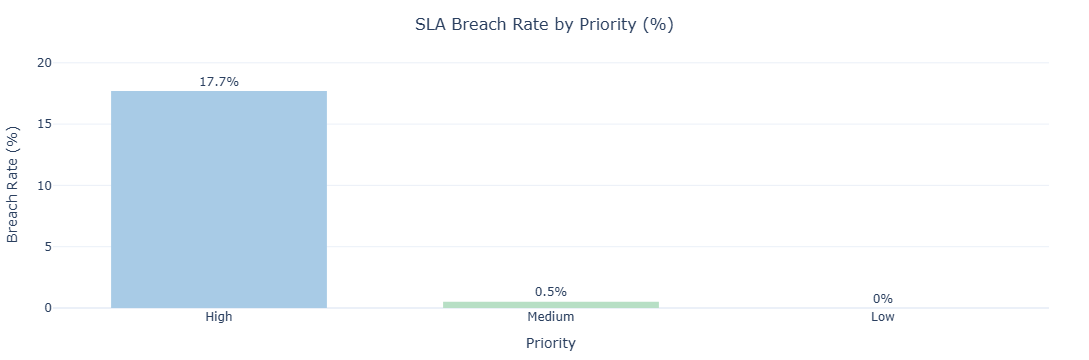

In [34]:
# Побудова bar chart для візуалізації SLA breach rate по priority
fig = px.bar(
    sla_summary,
    x='priority',
    y='breach_rate_pct',
    color='priority',
    text='breach_rate_pct',
    title='SLA Breach Rate by Priority (%)',
    color_discrete_sequence=pastel_palette,
    labels={
        'breach_rate_pct': 'Breach Rate (%)',
        'priority': 'Priority'
    }
)

fig.update_traces(
    texttemplate='%{text}%',
    textposition='outside',
    marker_line_width=0
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=16),
    font=dict(size=12),
    height=360,
    bargap=0.35,
    margin=dict(l=40, r=40, t=60, b=40),
    showlegend=False,
    yaxis_title='Breach Rate (%)'
)

fig.show()

### Аналіз результатів

High priority incidents демонструють найвищий рівень SLA breaches – 17,7% (1 143 інциденти), тоді як для Medium priority цей показник становить лише 0,5%, а для Low – 0%.

Незважаючи на те, що High priority incidents мають найшвидший average resolution time, саме такі інциденти найчастіше порушують SLA. Це може бути пов’язано з більш жорсткими SLA thresholds для критичних кейсів.

Водночас Medium та Low priority incidents переважно обробляються в межах встановлених SLA thresholds.

### Business Question 4: Як escalation process впливає на resolution time?

Аналізуємо, чи інциденти з ескалацією вирішуються довше та як escalation process пов’язаний із resolution time. Це дозволяє оцінити вплив escalation на операційну ефективність процесу.

Гіпотеза: ескаловані інциденти вирішуються довше.

In [35]:
# Порівняння resolution time для ескалованих
# та неескалованих інцидентів
escalation_impact = (
    incident_df
    .groupby('is_escalated')['resolution_hours']
    .agg(
        incident_count='count',
        avg_hours='mean',
        median_hours='median',
        max_hours='max'
    )
    .round(1)
    .reset_index()
)

# Заміна булевих значень на читабельні мітки
escalation_impact['is_escalated'] = (
    escalation_impact['is_escalated']
    .map({False: 'Not Escalated', True: 'Escalated'})
)

escalation_impact

,is_escalated,incident_count,avg_hours,median_hours,max_hours
0,Not Escalated,12747,11.5,9.5,46.3
1,Escalated,18841,17.4,14.2,56.3


Для перевірки статистичної значущості різниці використовується independent samples t-test.

In [36]:
# Формування груп для t-test
escalated = incident_df.loc[
    incident_df['is_escalated'],
    'resolution_hours'
]

not_escalated = incident_df.loc[
    ~incident_df['is_escalated'],
    'resolution_hours'
]

In [37]:
from scipy import stats

stat, p_value = stats.ttest_ind(
    escalated,
    not_escalated,
)

print(f'T-statistic: {stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(
    'Висновок: різниця статистично '
    f'{"значуща" if p_value < 0.05 else "незначуща"}'
    ' (alpha = 0.05)'
)

T-statistic: 60.0534
P-value: 0.000000
Висновок: різниця статистично значуща (alpha = 0.05)


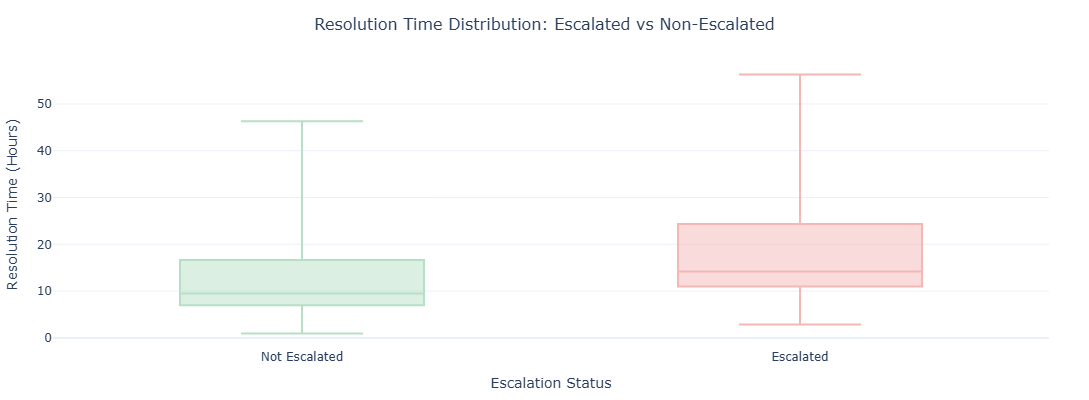

In [38]:
# Додаємо читабельну мітку для осі X
incident_df['escalation_label'] = incident_df['is_escalated'].map(
    {False: 'Not Escalated', True: 'Escalated'}
)

# Box plot для порівняння розподілу resolution time
# між ескалованими та неескалованими інцидентами
fig = px.box(
    incident_df,
    x='escalation_label',
    y='resolution_hours',
    color='escalation_label',
    title='Resolution Time Distribution: Escalated vs Non-Escalated',
    category_orders={
        'escalation_label': ['Not Escalated', 'Escalated']
    },
    color_discrete_map={
        'Not Escalated': '#B7DFC5',
        'Escalated': '#F2B8B5'
    },
    labels={
        'escalation_label': 'Escalation Status',
        'resolution_hours': 'Resolution Time (Hours)'
    },
    points=False
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=16),
    font=dict(size=12),
    height=400,
    margin=dict(l=40, r=40, t=60, b=40),
    showlegend=False
)

fig.show()

### Аналіз результатів

Гіпотезу підтверджено: ескаловані інциденти вирішуються в середньому на 51% довше (17,4 h vs 11,5 h), а різниця є статистично значущою (t = 60,05, p < 0,0001). Це свідчить про стійкий зв’язок між escalation process і збільшенням resolution time. Медіанний час вирішення також є вищим для escalated incidents (14,2 h vs 9,5 h).

18 841 із 31 588 інцидентів (59,6%) проходили через escalation process, що свідчить про високу залежність workflow від передачі задач між support levels. Це може вказувати на потенційні inefficiencies у first-level support process та створювати додаткове операційне навантаження. Зменшення escalation rate може бути одним із напрямів підвищення операційної ефективності.

### Business Question 5: Як report channel впливає на SLA breaches?

Аналізуємо залежність між каналом звернення та рівнем SLA breaches у розрізі priority. Це дозволяє визначити які канали створюють найбільше операційних ризиків.

In [39]:
# SQL-запит для аналізу SLA breach rate
# по report channel та priority
query = """
SELECT
    report_channel,
    priority,
    COUNT(*) AS total_incidents,
    COUNTIF(sla_breached) AS breached_count,
    ROUND(
        COUNTIF(sla_breached) * 100.0 / COUNT(*),
        1
    ) AS breach_rate_pct
FROM `operational-efficiency-project.operational_efficiency.incident_metrics`
GROUP BY report_channel, priority
ORDER BY report_channel, priority
"""

# Отримання результатів з BigQuery
channel_sla = client.query(query).to_dataframe()

# Логічний порядок priority
channel_sla['priority'] = pd.Categorical(
    channel_sla['priority'],
    categories=['High', 'Medium', 'Low'],
    ordered=True
)

channel_sla.head(10)

,report_channel,priority,total_incidents,breached_count,breach_rate_pct
0,App,High,407,58,14.3
1,App,Low,551,0,0.0
2,App,Medium,948,4,0.4
3,Email,High,2476,456,18.4
4,Email,Low,3629,0,0.0
5,Email,Medium,5925,35,0.6
6,Phone,High,190,33,17.4
7,Phone,Low,266,0,0.0
8,Phone,Medium,477,1,0.2
9,Website,High,3393,596,17.6


In [40]:
# Формування pivot table для heatmap
# рядки — priority, стовпці — report channel
channel_pivot = channel_sla.pivot(
    index='priority',
    columns='report_channel',
    values='breach_rate_pct'
)

channel_pivot

report_channel,App,Email,Phone,Website
priority,,,,
High,14.3,18.4,17.4,17.6
Medium,0.4,0.6,0.2,0.5
Low,0.0,0.0,0.0,0.0


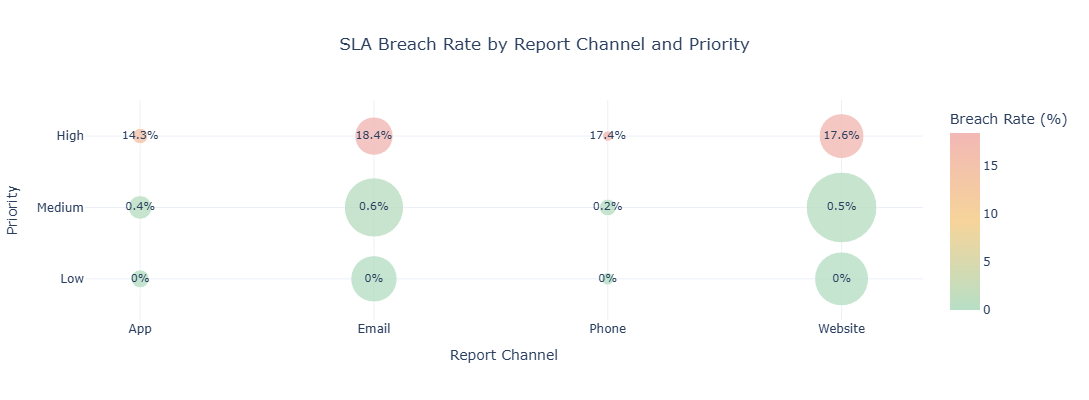

In [41]:
# Bubble chart для візуалізації SLA breaches
# по report channel та priority
fig = px.scatter(
    channel_sla,
    x='report_channel',
    y='priority',
    size='total_incidents',
    color='breach_rate_pct',
    text='breach_rate_pct',
    title='SLA Breach Rate by Report Channel and Priority',
    color_continuous_scale=[
        [0.0, '#B7DFC5'],
        [0.5, '#F6D49A'],
        [1.0, '#F2B8B5']
    ],
    labels={
        'report_channel': 'Report Channel',
        'priority': 'Priority',
        'breach_rate_pct': 'Breach Rate (%)',
        'total_incidents': 'Total Incidents'
    },
    category_orders={'priority': ['High', 'Medium', 'Low']},
    size_max=50
)

fig.update_traces(
    marker=dict(opacity=0.8),
    texttemplate='%{text}%',
    textposition='middle center',
    textfont=dict(size=11)
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=400,
    coloraxis_colorbar=dict(title='Breach Rate (%)')
)

fig.show()

### Аналіз результатів

SLA breaches концентруються виключно у High priority інцидентах, незалежно від каналу звернення. Найвищий breach rate демонструє Email (18,4%), за ним – Website (17,6%), Phone (17,4%)  та App (14,3%). Medium priority інциденти показують мінімальний рівень SLA breaches (0,2–0,6%), тоді як Low priority інциденти не мають порушень SLA.

Нижчий breach rate для App може свідчити про більш ефективний процес обробки звернень через цей канал. Email демонструє найвищий рівень SLA breaches серед High priority incidents та потребує додаткової операційної уваги щодо швидкості обробки звернень.

### Business Question 6: У які години та дні спостерігається пікове операційне навантаження?

Аналізуємо розподіл операційного навантаження по годинах та днях тижня. Це дозволяє визначити пікові періоди та оптимізувати staffing та resource allocation.

In [42]:
# Правильний порядок днів тижня
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Підрахунок інцидентів по дню та годині
workload_pivot = (
    incident_df
    .groupby(['open_day', 'open_hour'])
    .size()
    .reset_index(name='incident_count')
    .pivot(
        index='open_day',
        columns='open_hour',
        values='incident_count'
    )
    .reindex(day_order)
    .fillna(0)
    .astype(int)
)

workload_pivot

open_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
open_day,,,,,,,,,,,,,,,,,,,,,
Monday,214,209,218,184,164,174,180,180,199,185,...,194,191,186,180,181,188,186,207,175,201
Tuesday,177,191,190,198,176,184,188,185,196,202,...,194,208,188,197,177,186,175,171,185,181
Wednesday,194,171,199,193,212,186,210,199,173,193,...,196,184,194,185,175,167,183,184,201,167
Thursday,186,212,186,172,158,176,176,181,185,174,...,181,190,189,150,199,191,179,182,215,174
Friday,188,167,186,193,163,195,176,184,199,185,...,209,189,202,187,176,170,208,190,179,180
Saturday,185,183,223,184,203,181,178,188,183,172,...,185,187,183,177,171,195,193,188,209,190
Sunday,199,182,179,181,198,222,187,190,192,173,...,177,189,206,193,172,175,191,217,199,195


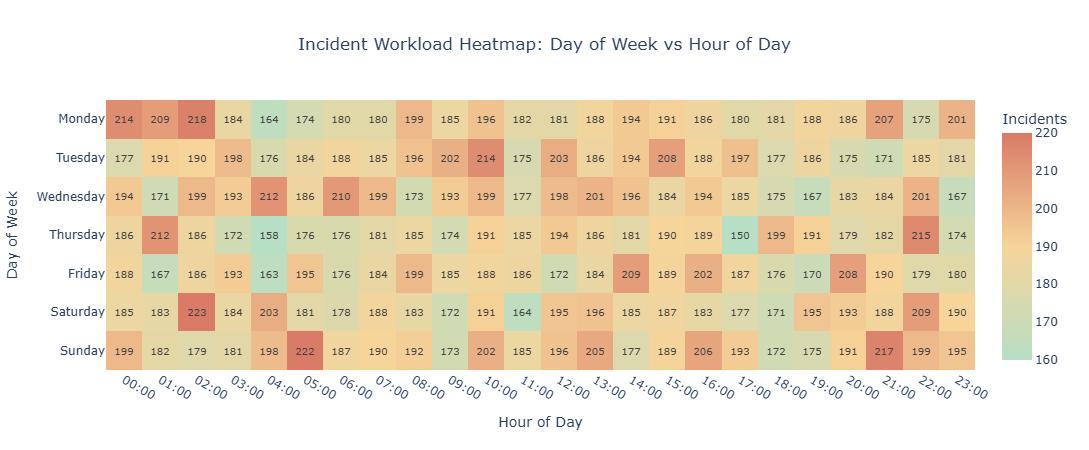

In [43]:
# Workload heatmap по днях та годинах
# Пастельна палітра
pastel_workload_colorscale = [
    [0.0, '#B7DFC5'],
    [0.5, '#F6D49A'],
    [1.0, '#D97B66']
]

# Фіксований діапазон для кращої видимості різниці між значеннями
fig = go.Figure(
    data=go.Heatmap(
        z=workload_pivot.values,
        x=[f'{h:02d}:00' for h in workload_pivot.columns],
        y=workload_pivot.index.tolist(),
        colorscale=pastel_workload_colorscale,
        zmin=160,
        zmax=220,
        colorbar=dict(title='Incidents'),
        text=workload_pivot.values,
        texttemplate='%{text}',
        textfont=dict(size=10)
    )
)

fig.update_layout(
    title='Incident Workload Heatmap: Day of Week vs Hour of Day',
    template='plotly_white',
    title_x=0.5,
    height=450,
    xaxis_title='Hour of Day',
    yaxis_title='Day of Week',
    yaxis=dict(autorange='reversed')
)

fig.show()

### Аналіз результатів

Операційне навантаження розподілене відносно рівномірно протягом тижня та доби: кількість інцидентів коливається приблизно від 150 до 223 на годину. Це свідчить про відсутність різко виражених пікових періодів.

Водночас можна виділити окремі локальні піки: Saturday 02:00 (223), Sunday 05:00 (222), Monday 02:00 (218) та Thursday 21:00 (215). Частина пікових значень припадає на нічні години та вихідні дні.

Це може свідчити про потребу в стабільному staffing coverage та моніторингу навантаження не лише у стандартні робочі години.

### Business Question 7: Який вплив issue type на resolution time?

Аналізуємо середній час вирішення інцидентів залежно від типу issue. Це дозволяє визначити, які категорії інцидентів мають найбільший вплив на operational workload.

In [44]:
# Розрахунок resolution time metrics по issue type
resolution_by_type = (
    incident_df
    .groupby('issue_type')['resolution_hours']
    .agg(
        incident_count='count',
        avg_hours='mean',
        median_hours='median',
        max_hours='max'
    )
    .round(1)
    .reset_index()
    .sort_values('avg_hours', ascending=False)
)

resolution_by_type

,issue_type,incident_count,avg_hours,median_hours,max_hours
0,Bug,6804,16.0,12.0,56.3
4,Performance Issue,8128,15.2,13.2,47.4
3,Maintenance,1558,14.7,12.5,46.6
6,Technical Issue,1515,14.7,12.8,46.6
1,Feature Request,6118,14.6,12.5,52.3
2,Incident,4463,14.6,12.5,47.7
5,Service Request,3002,14.3,12.1,46.7


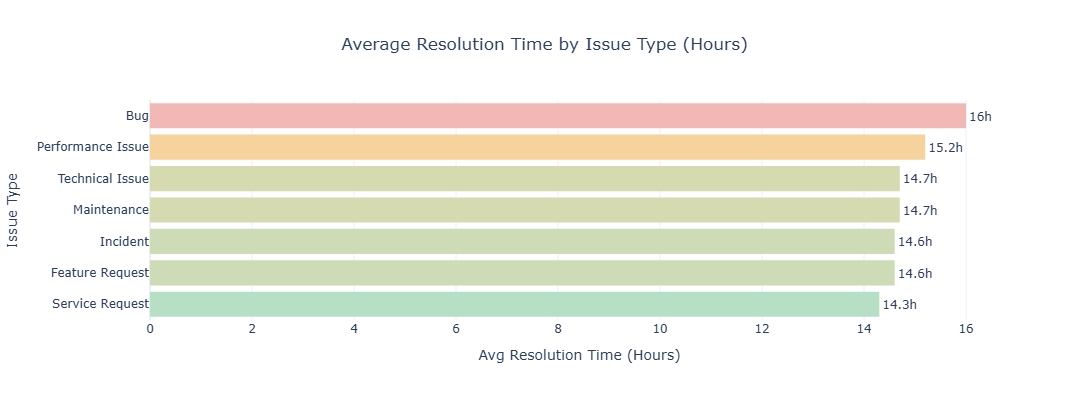

In [45]:
# Horizontal bar chart для порівняння
# resolution time по issue type
fig = px.bar(
    resolution_by_type,
    x='avg_hours',
    y='issue_type',
    orientation='h',
    color='avg_hours',
    text='avg_hours',
    title='Average Resolution Time by Issue Type (Hours)',
    color_continuous_scale=[
        [0.0, '#B7DFC5'],
        [0.5, '#F6D49A'],
        [1.0, '#F2B8B5']
    ],
    labels={
        'avg_hours': 'Avg Resolution Time (Hours)',
        'issue_type': 'Issue Type'
    }
)

fig.update_traces(
    texttemplate='%{text}h',
    textposition='outside',
    marker_line_width=0
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=400,
    showlegend=False,
    coloraxis_showscale=False,
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

### Аналіз результатів

Bug incidents мають найвищий середній час вирішення – 16,0 години, що на 11,9% більше ніж у найшвидшої категорії Service Request (14,3 h). Performance Issues займають друге місце (15,2 h), що корелює з їхнім домінуванням у всіх priority-категоріях (BQ1).

Загалом різниця між issue types залишається невеликою (14,3–16,0 h), що може свідчити про достатньо стандартизований workflow обробки інцидентів. 

Проте Bug та Performance Issues потребують додаткової уваги, тому що саме вони формують найбільший workload та мають найвищий resolution time.

### Business Question 8: Який зв'язок між кількістю escalations та resolution time?

Аналізуємо кореляцію між кількістю ескалацій та часом вирішення інцидентів. Це дозволяє кількісно оцінити операційну вартість кожної додаткової ескалації.

Гіпотеза: Чим більше ескалацій проходить інцидент – тим довше він вирішується.

In [46]:
# Середній resolution time по кількості ескалацій
resolution_by_escalation = (
    incident_df
    .groupby('escalation_count')['resolution_hours']
    .agg(
        incident_count='count',
        avg_hours='mean',
        median_hours='median'
    )
    .round(1)
    .reset_index()
)

resolution_by_escalation

,escalation_count,incident_count,avg_hours,median_hours
0,0,12747,11.5,9.5
1,1,16862,16.7,13.8
2,2,718,18.7,15.6
3,3,1261,26.6,22.2


In [47]:
# Розрахунок кореляції між кількістю ескалацій
# та часом вирішення інцидентів
correlation = incident_df['escalation_count'].corr(
    incident_df['resolution_hours']
)

print(f'Pearson correlation coefficient: {correlation:.4f}')

Pearson correlation coefficient: 0.3827


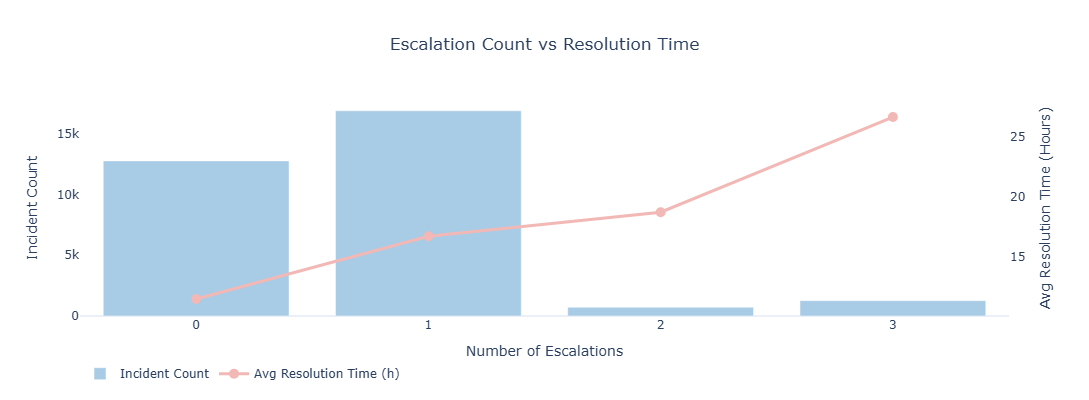

In [48]:
# Bar + line chart для візуалізації зв'язку
# між кількістю ескалацій та resolution time
fig = go.Figure()

# Bar — кількість інцидентів
fig.add_bar(
    x=resolution_by_escalation['escalation_count'],
    y=resolution_by_escalation['incident_count'],
    name='Incident Count',
    marker_color='#A8CBE6',
    yaxis='y1'
)

# Line — середній resolution time
fig.add_scatter(
    x=resolution_by_escalation['escalation_count'],
    y=resolution_by_escalation['avg_hours'],
    name='Avg Resolution Time (h)',
    mode='lines+markers',
    line=dict(color='#F2B8B5', width=3),
    marker=dict(size=10),
    yaxis='y2'
)

fig.update_layout(
    title='Escalation Count vs Resolution Time',
    template='plotly_white',
    title_x=0.5,
    height=400,
    xaxis=dict(
        title='Number of Escalations',
        tickvals=[0, 1, 2, 3]
    ),
    yaxis=dict(
        title='Incident Count',
        showgrid=False
    ),
    yaxis2=dict(
        title='Avg Resolution Time (Hours)',
        overlaying='y',
        side='right',
        showgrid=False
    ),
    legend=dict(orientation='h', y=-0.2)
)

fig.show()

### Аналіз результатів

Гіпотезу підтверджено: Pearson correlation coefficient становить r = 0,38 (помірна позитивна кореляція), тобто існує позитивний зв'язок між кількістю ескалацій та resolution time.

Кожна додаткова ескалація асоціюється зі збільшенням resolution time: інциденти без ескалацій вирішуються в середньому за 11,5 години, з однією ескалацією – 16,7 години (+45%), з двома – 18,7 години (+63%), з трьома – 26,6 години (+131%).

Найбільша частка інцидентів проходить через одну ескалацію (16 862 кейси), що свідчить про високу залежність workflow від передачі задач між support levels. Це може вказувати на potential inefficiencies у first-line support process або routing workflow.

Інциденти з трьома ескалаціями (1 261 кейс) демонструють найвищий рівень затримок – їхній average resolution time більш ніж на 130% перевищує базовий рівень. Це свідчить про те, що зниження кількості escalation може бути одним із напрямів підвищення операційної ефективності.

### Business Question 9: Як resolution time впливає на Customer Satisfaction?

Аналізуємо зв'язок між часом вирішення інцидентів та рівнем задоволеності клієнтів. Це дозволяє оцінити операційний вплив resolution time на customer experience.

Гіпотеза: Інциденти з довшим часом вирішення матимуть нижчий CSAT score.

In [49]:
# Розрахунок середнього resolution time
# та кількості інцидентів по CSAT score
csat_analysis = (
    incident_df
    .groupby('csat')['resolution_hours']
    .agg(
        incident_count='count',
        avg_hours='mean',
        median_hours='median'
    )
    .round(1)
    .reset_index()
)

csat_analysis

,csat,incident_count,avg_hours,median_hours
0,1,3401,15.9,12.7
1,2,3685,14.8,12.1
2,3,9885,15.1,12.7
3,4,10628,14.9,12.9
4,5,3989,14.8,12.8


In [50]:
# Кореляція між CSAT score та resolution time
csat_correlation = incident_df['csat'].corr(
    incident_df['resolution_hours']
)

print(f'Pearson correlation coefficient: {csat_correlation:.4f}')

Pearson correlation coefficient: -0.0257


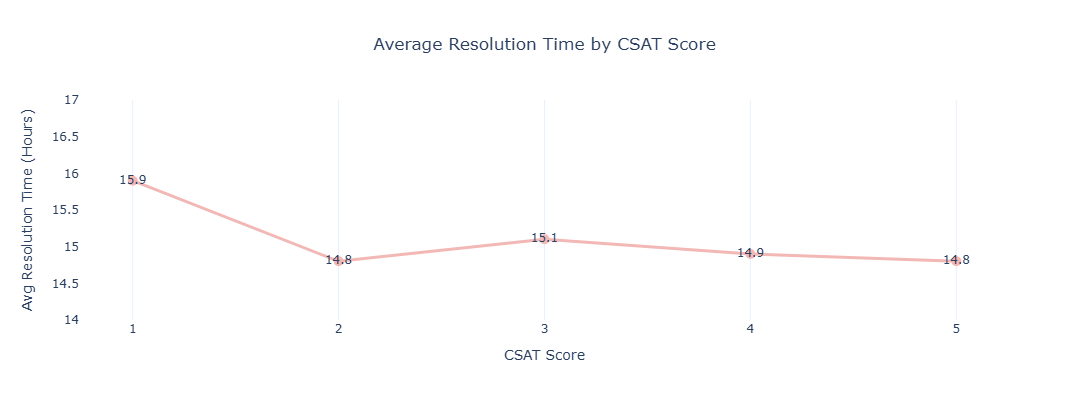

In [51]:
# Line chart для візуалізації зв'язку
# між CSAT score та average resolution time
fig = px.line(
    csat_analysis,
    x='csat',
    y='avg_hours',
    text='avg_hours',
    markers=True,
    title='Average Resolution Time by CSAT Score',
    labels={
        'csat': 'CSAT Score',
        'avg_hours': 'Avg Resolution Time (Hours)'
    }
)

fig.update_traces(
    line=dict(color='#F2B8B5', width=3),
    marker=dict(size=10, color='#F2B8B5'),
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=400,
    xaxis=dict(dtick=1),
    yaxis=dict(
        range=[14, 17],
        showgrid=False
    )
)

fig.show()

### Аналіз результатів

Гіпотезу скасовано: Pearson correlation coefficient становить r = -0,03, що свідчить про практично відсутній зв’язок між resolution time та CSAT.

Середній час вирішення залишається відносно стабільним для всіх рівнів CSAT (14,8–15,9 h), тому resolution time не є ключовим фактором satisfaction score у цьому датасеті.

Ймовірно, customer satisfaction більшою мірою залежить від інших факторів, зокрема якості комунікації, складності інциденту або загального customer experience.

### Business Question 10: Як reopened інциденти впливають на operational efficiency?

Аналізуємо рівень reopened інцидентів та їх вплив на resolution time. Це дозволяє оцінити якість первинного вирішення інцидентів і виявити potential workflow inefficiencies.

In [52]:
# Розрахунок reopened rate та resolution time metrics
reopened_analysis = (
    incident_df
    .groupby('is_reopened')['resolution_hours']
    .agg(
        incident_count='count',
        avg_hours='mean',
        median_hours='median',
        max_hours='max'
    )
    .round(1)
    .reset_index()
)

# Заміна булевих значень на читабельні мітки
reopened_analysis['is_reopened'] = (
    reopened_analysis['is_reopened']
    .map({False: 'Not Reopened', True: 'Reopened'})
)

reopened_analysis

,is_reopened,incident_count,avg_hours,median_hours,max_hours
0,Not Reopened,30400,14.7,12.5,56.3
1,Reopened,1188,23.3,19.4,52.3


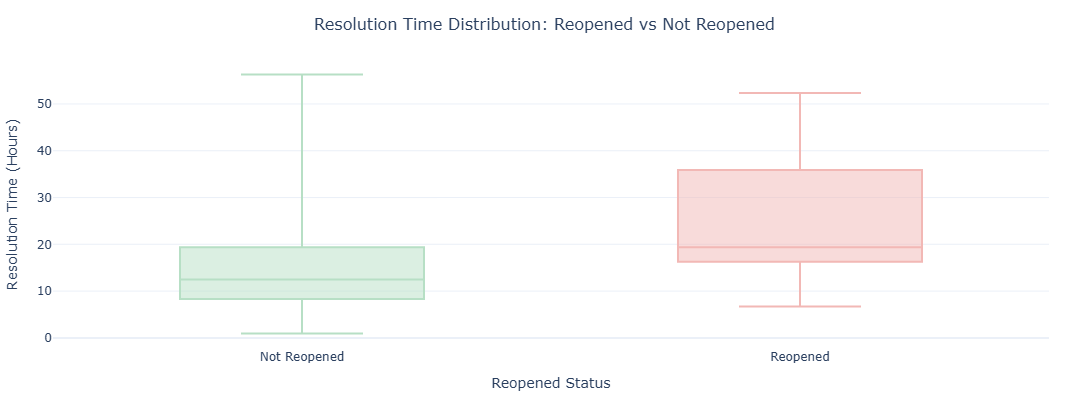

In [53]:
# Додаємо читабельну мітку для графіка
incident_df['reopened_label'] = incident_df['is_reopened'].map(
    {False: 'Not Reopened', True: 'Reopened'}
)

# Box plot для порівняння resolution time
# між reopened та not reopened incidents
fig = px.box(
    incident_df,
    x='reopened_label',
    y='resolution_hours',
    color='reopened_label',
    title=(
    'Resolution Time Distribution: '
    'Reopened vs Not Reopened'
),
    category_orders={
        'reopened_label': ['Not Reopened', 'Reopened']
    },
    color_discrete_map={
        'Not Reopened': '#B7DFC5',
        'Reopened': '#F2B8B5'
    },
    labels={
        'reopened_label': 'Reopened Status',
        'resolution_hours': 'Resolution Time (Hours)'
    },
    points=False
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=16),
    font=dict(size=12),
    height=400,
    margin=dict(l=40, r=40, t=60, b=40),
    showlegend=False
)

fig.show()

### Аналіз результатів

Reopened incidents становлять лише близько 3,8% усіх інцидентів, проте мають суттєво вищий resolution time. Середній час вирішення reopened incidents становить 23,3 години проти 14,7 години для not reopened cases (+58%).

Box plot також показує значно ширший розподіл resolution time для reopened incidents, що може свідчити про вищу складність таких кейсів.

Це може вказувати на potential inefficiencies у first-time resolution process або на передчасне закриття інцидентів. Попри невеликий reopen rate, reopened cases створюють додаткове операційне навантаження та негативно впливають на workflow efficiency.

# 6. Operational Insights & Recommendations

## Operational KPI Summary by Priority

Таблиця узагальнює ключові операційні KPI у розрізі priority incidents. Вона дозволяє порівняти рівень SLA breaches, resolution time, escalation activity та reopened rate між різними priority groups і визначити основні зони операційного ризику та workflow bottlenecks.

In [54]:
# Executive summary table по priority
executive_summary = (
    incident_df
    .groupby('priority')
    .agg(
        total_incidents=('Case ID', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        sla_breach_rate=('sla_breached', 'mean'),
        escalation_rate=('is_escalated', 'mean'),
        avg_escalations=('escalation_count', 'mean'),
        reopened_rate=('is_reopened', 'mean')
    )
    .reset_index()
)

# Конвертація rate metrics у %
rate_columns = [
    'sla_breach_rate',
    'escalation_rate',
    'reopened_rate'
]

executive_summary[rate_columns] = (
    executive_summary[rate_columns] * 100
)

# Округлення числових значень
executive_summary = executive_summary.round(1)

# Логічний порядок priority categories
priority_order = ['High', 'Medium', 'Low']

executive_summary['priority'] = pd.Categorical(
    executive_summary['priority'],
    categories=priority_order,
    ordered=True
)

# Сортування таблиці за priority
executive_summary = (
    executive_summary
    .sort_values('priority')

    # Читабельні назви колонок для executive view
    .rename(columns={
        'priority': 'Priority',
        'total_incidents': 'Total Incidents',
        'avg_resolution_hours': 'Avg Resolution (h)',
        'sla_breach_rate': 'SLA Breach Rate (%)',
        'escalation_rate': 'Escalation Rate (%)',
        'avg_escalations': 'Avg Escalations',
        'reopened_rate': 'Reopened Rate (%)'
    })
)

executive_summary

,Priority,Total Incidents,Avg Resolution (h),SLA Breach Rate (%),Escalation Rate (%),Avg Escalations,Reopened Rate (%)
0,High,6466,6.2,17.7,60.0,0.7,3.7
2,Medium,15774,12.3,0.5,59.0,0.7,3.7
1,Low,9348,25.8,0.0,60.5,0.7,3.9


## Key Operational Findings

- SLA Performance: High priority incidents є основною зоною операційного ризику – SLA breach rate становить 18% (1 143 інциденти). Medium та Low priority практично не порушують SLA (0,5% і 0% відповідно).

- Escalation Impact: 59,6% усіх інцидентів були ескаловані, що свідчить про високу залежність workflow від передачі задач між support levels. Кожна ескалація збільшує resolution time в середньому на 5,9 години (11,5 h - 17,4 h, +51%).

- Reopened Incidents: 3,8% інцидентів повторно відкриваються клієнтами та вирішуються на 58% довше (23,3 h vs 14,7 h), що може вказувати на проблеми з first-time resolution quality.

- Report Channel Impact: Email channel демонструє найвищий SLA breach rate (18,4%), тоді як App має найнижчий показник (14,3%) серед High priority incidents, що може свідчити про більш ефективний процес обробки звернень.

- Workload Distribution: Операційне навантаження розподілене відносно рівномірно протягом доби з окремими локальними піками у нічні години та вихідні дні, що може свідчити про потребу у цілодобовому staffing coverage.

- Issue Type Impact: Bug та Performance Issues є найбільш ресурсоємними типами інцидентів (16,0 h та 15,2 h відповідно) і мають найвищий average resolution time серед усіх issue categories.

- Customer Satisfaction: Resolution time має мінімальний вплив на CSAT (r = -0.03), тому customer satisfaction, ймовірно, залежить від інших факторів – якості комунікації, складності інциденту та загального customer experience.

## Operational Recommendations

- Посилити SLA monitoring для High priority incidents: поточний breach rate 18% (1 143 інциденти) вказує на потребу в більш оперативному контролі SLA-sensitive cases та real-time alerting.

- Оптимізувати first-line support process: escalation rate 59,6% свідчить про високу залежність workflow від передачі задач між support levels. Додатковий training та knowledge base optimization можуть допомогти скоротити кількість escalations.

- Провести аналіз причин reopened incidents: reopen rate 3,8% при +58% resolution time створює додаткове операційне навантаження. Доцільно впровадити додатковий quality check перед закриттям інцидентів.

- Оптимізувати Email handling workflow: Email channel має найвищий SLA breach rate серед High priority incidents, тому потребує додаткової уваги до швидкості обробки звернень.

- Переглянути staffing model: локальні піки навантаження у нічні години та вихідні дні можуть свідчити про потребу у більш стабільному staffing coverage. Розглянути 24/7 coverage або асинхронний workflow для нічних годин.

- Створити окремі handling procedures для Bug та Performance Issues – ці категорії мають найвищий average resolution time (16,0 h та 15,2 h) серед усіх issue types.

- Впровадити SLA monitoring dashboard для real-time відстеження breach rate та раннього виявлення potential bottlenecks.

- Запровадити регулярний щомісячний operational review на основі ключових KPI: SLA breach rate, escalation rate, reopened rate – для моніторингу прогресу та своєчасного виявлення нових bottlenecks.